Synthetic data = artificially generated data that mimics real-world patterns.
Used for:
Model testing
Data augmentation
Privacy-safe datasets
Simulation (like machine failure, sensor signals)

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 5000

time = np.arange(n_samples)

# Base signals
blast_temp = 1100 + 20*np.sin(time/200) + np.random.normal(0, 5, n_samples)
blast_pressure = 2.5 + 0.1*np.sin(time/150) + np.random.normal(0, 0.05, n_samples)
o2_percent = 21 + np.random.normal(0, 0.3, n_samples)
pci_rate = 150 + 10*np.sin(time/300) + np.random.normal(0, 3, n_samples)

topgas_co = 22 + np.random.normal(0, 1, n_samples)
topgas_co2 = 18 + np.random.normal(0, 1, n_samples)

tuyere_temp = 1800 + 30*np.sin(time/100) + np.random.normal(0, 10, n_samples)
cooling_deltaT = 15 + np.random.normal(0, 1, n_samples)
shell_temp = 300 + np.random.normal(0, 5, n_samples)
vibration = 2 + np.random.normal(0, 0.2, n_samples)

# Simulate degradation
degradation = np.linspace(0, 200, n_samples)
shell_temp += degradation * 0.05
tuyere_temp += degradation * 0.1
vibration += degradation * 0.005

# RUL (decreasing)
RUL = np.maximum(200 - degradation, 0)

# Failure Types
failure_type = np.zeros(n_samples)

# Inject failures
for i in range(1000, 5000, 1000):
    failure_type[i:i+50] = 1  # Tuyere failure
    tuyere_temp[i:i+50] += 200

for i in range(1500, 5000, 1500):
    failure_type[i:i+50] = 2  # Cooling failure
    cooling_deltaT[i:i+50] += 10
    shell_temp[i:i+50] += 50

# Anomalies
anomaly = np.zeros(n_samples)
anomaly_idx = np.random.choice(n_samples, size=200, replace=False)

blast_temp[anomaly_idx] += np.random.normal(100, 20, len(anomaly_idx))
vibration[anomaly_idx] += np.random.normal(2, 0.5, len(anomaly_idx))
anomaly[anomaly_idx] = 1

#Create DataFrame
df = pd.DataFrame({
    "Time": time,
    "BlastTemp": blast_temp,
    "BlastPressure": blast_pressure,
    "O2Percent": o2_percent,
    "PCI_Rate": pci_rate,
    "TopGas_CO": topgas_co,
    "TopGas_CO2": topgas_co2,
    "TuyereTemp": tuyere_temp,
    "CoolingWater_DeltaT": cooling_deltaT,
    "ShellTemp": shell_temp,
    "Vibration": vibration,
    "RUL": RUL,
    "FailureType": failure_type,
    "Anomaly": anomaly
})

print(df.head())

# Save dataset
df.to_csv("blast_furnace_synthetic_data.csv", index=False)

   Time    BlastTemp  BlastPressure  O2Percent    PCI_Rate  TopGas_CO  \
0     0  1102.483571       2.478812  20.796452  149.569730  22.348286   
1     1  1099.408678       2.477996  20.908350  149.935366  22.283324   
2     2  1103.438439       2.411551  20.820786  150.259551  21.063480   
3     3  1107.915138       2.485495  21.033125  152.940583  22.579584   
4     4  1099.229206       2.539308  21.359154  147.891677  20.509917   

   TopGas_CO2   TuyereTemp  CoolingWater_DeltaT   ShellTemp  Vibration  \
0   18.170874  1780.194280            15.914098  297.640712   2.209956   
1   18.012255  1789.754139            16.624487  305.065513   1.844093   
2   17.568845  1794.737678            15.345517  299.013067   2.240281   
3   17.997473  1802.408557            14.744879  300.458848   1.988375   
4   18.490842  1811.457306            13.933275  303.594955   2.172031   

          RUL  FailureType  Anomaly  
0  200.000000          0.0      0.0  
1  199.959992          0.0      0.0  
2 

Basic infomation about the dataset

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Time                 5000 non-null   int64  
 1   BlastTemp            5000 non-null   float64
 2   BlastPressure        5000 non-null   float64
 3   O2Percent            5000 non-null   float64
 4   PCI_Rate             5000 non-null   float64
 5   TopGas_CO            5000 non-null   float64
 6   TopGas_CO2           5000 non-null   float64
 7   TuyereTemp           5000 non-null   float64
 8   CoolingWater_DeltaT  5000 non-null   float64
 9   ShellTemp            5000 non-null   float64
 10  Vibration            5000 non-null   float64
 11  RUL                  5000 non-null   float64
 12  FailureType          5000 non-null   float64
 13  Anomaly              5000 non-null   float64
dtypes: float64(13), int64(1)
memory usage: 547.0 KB


Description

In [3]:
df.describe()

,Time,BlastTemp,BlastPressure,O2Percent,PCI_Rate,TopGas_CO,TopGas_CO2,TuyereTemp,CoolingWater_DeltaT,ShellTemp,Vibration,RUL,FailureType,Anomaly
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2499.500000,1104.068987,2.503516,21.003166,150.995112,21.981648,17.993427,1817.912544,15.295783,306.589868,2.578738,100.000000,0.090000,0.040000
std,1443.520003,24.978255,0.087627,0.299631,7.537995,0.983375,0.999461,45.655452,1.956202,10.388149,0.534945,57.752351,0.376734,0.195979
min,0.000000,1064.187618,2.216399,19.987326,130.387958,18.344913,14.546646,1743.777776,11.551957,285.162852,1.415014,0.000000,0.000000,0.000000
25%,1249.750000,1087.243488,2.437459,20.801734,144.631269,21.298240,17.300775,1791.770401,14.338720,301.245342,2.245789,50.000000,0.000000,0.000000
50%,2499.500000,1101.022178,2.504689,21.002975,151.535740,21.991983,17.998957,1811.434763,15.048409,305.342985,2.514066,100.000000,0.000000,0.000000
75%,3749.250000,1114.942624,2.572037,21.202660,157.345375,22.650606,18.677442,1830.822148,15.742352,309.519989,2.804887,150.000000,0.000000,0.000000
max,4999.000000,1256.268498,2.746483,22.028673,169.182543,25.611350,21.691625,2060.138448,27.693249,369.384228,6.170488,200.000000,2.000000,1.000000


chaking is null value are present

In [4]:
df.isnull().sum()

Time                   0
BlastTemp              0
BlastPressure          0
O2Percent              0
PCI_Rate               0
TopGas_CO              0
TopGas_CO2             0
TuyereTemp             0
CoolingWater_DeltaT    0
ShellTemp              0
Vibration              0
RUL                    0
FailureType            0
Anomaly                0
dtype: int64

remove duplicate values

In [5]:
df.duplicated().sum()
df = df.drop_duplicates()

count failure type

In [6]:
df['FailureType'].value_counts()

FailureType
0.0    4700
1.0     150
2.0     150
Name: count, dtype: int64

visualize box plot for detect outlire

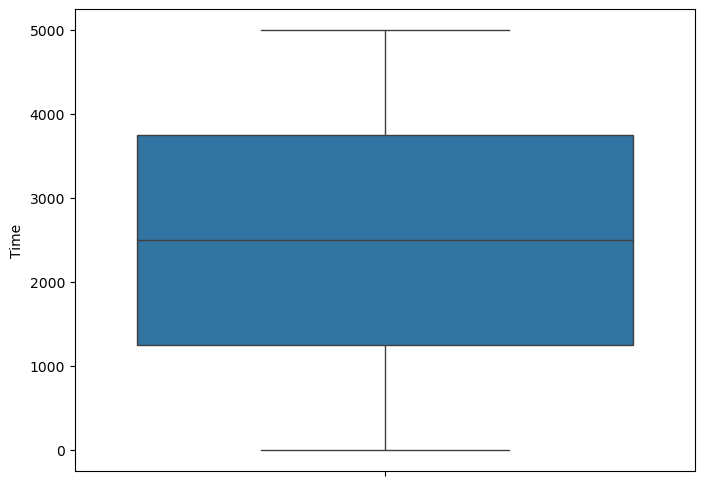

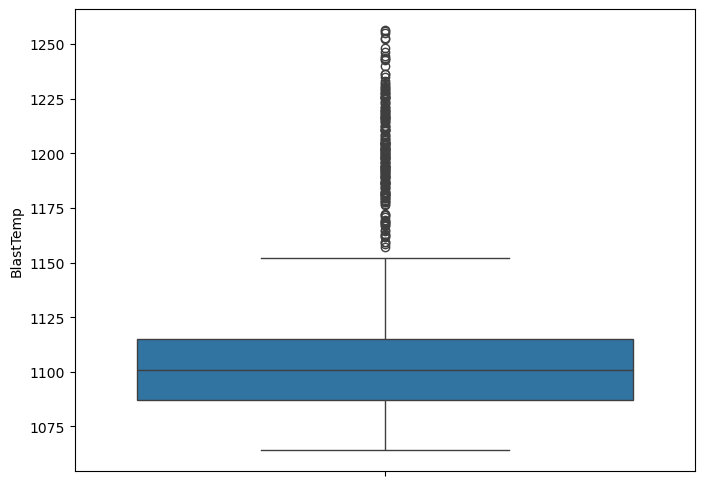

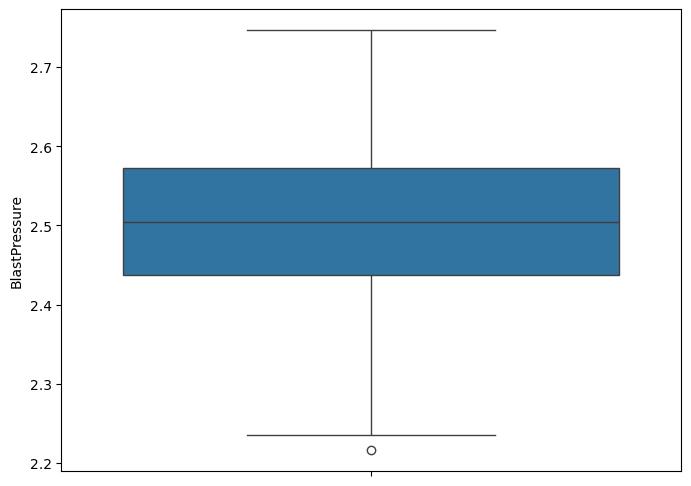

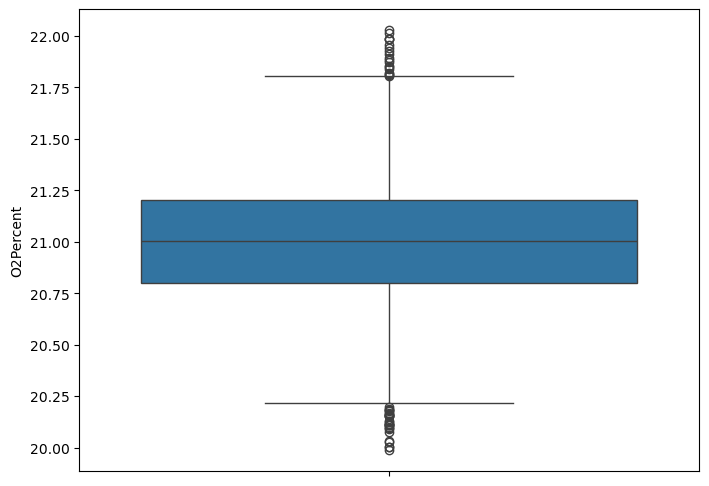

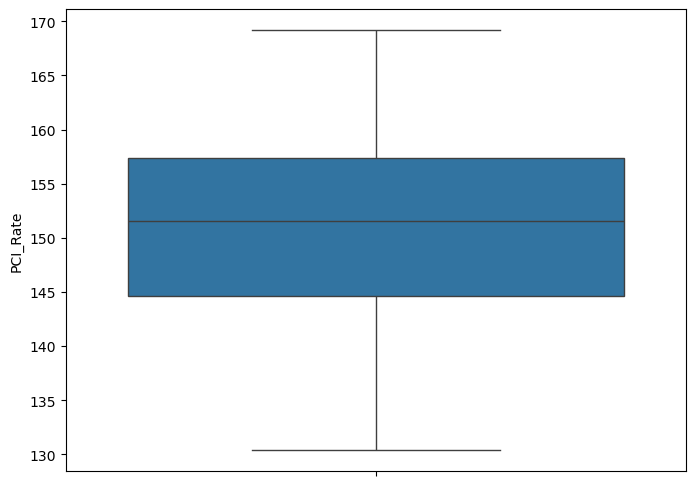

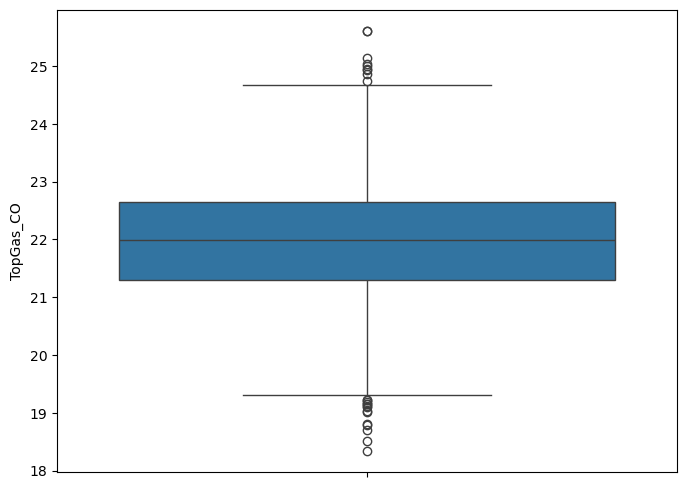

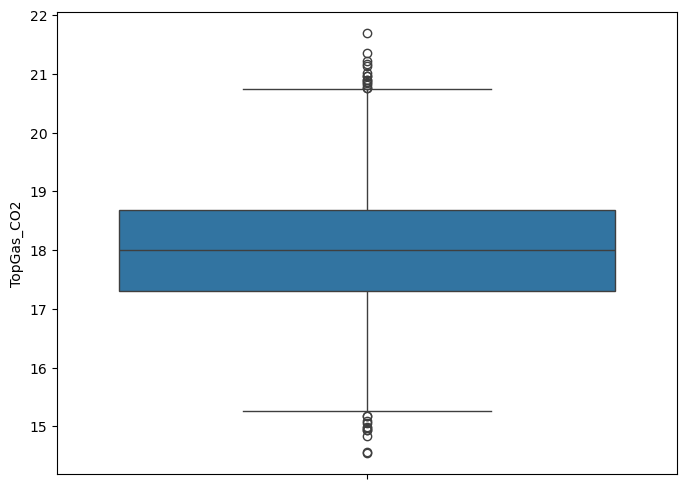

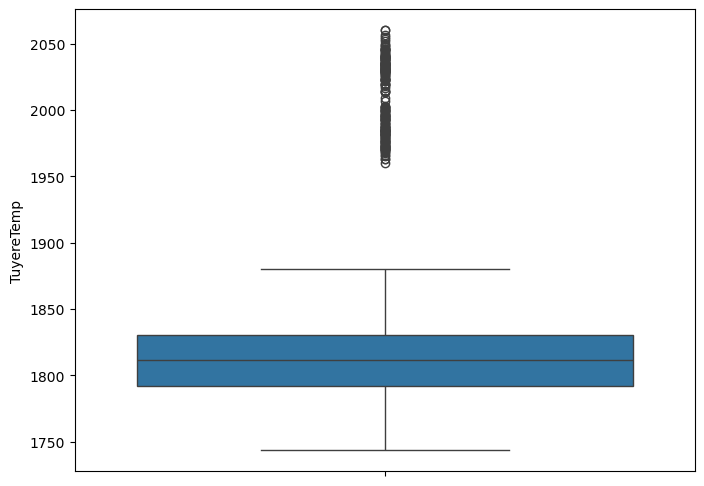

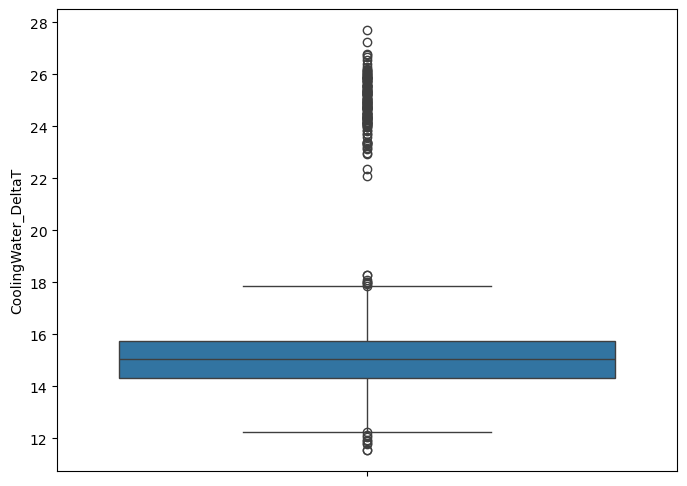

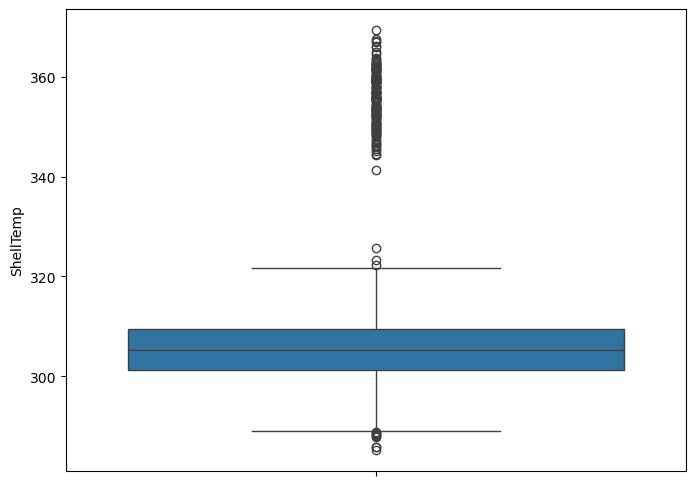

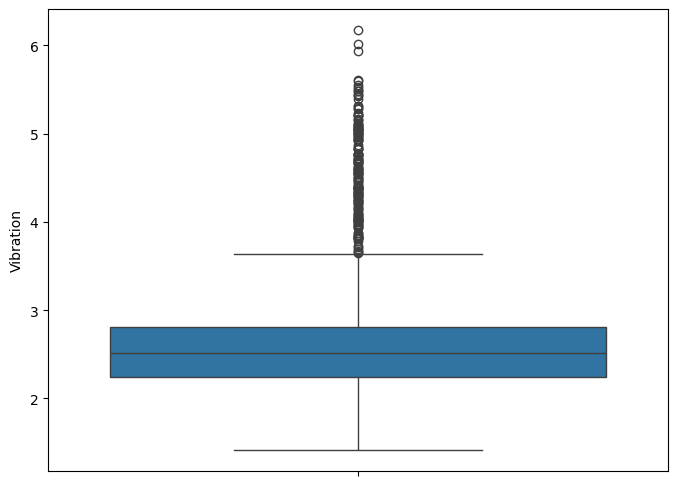

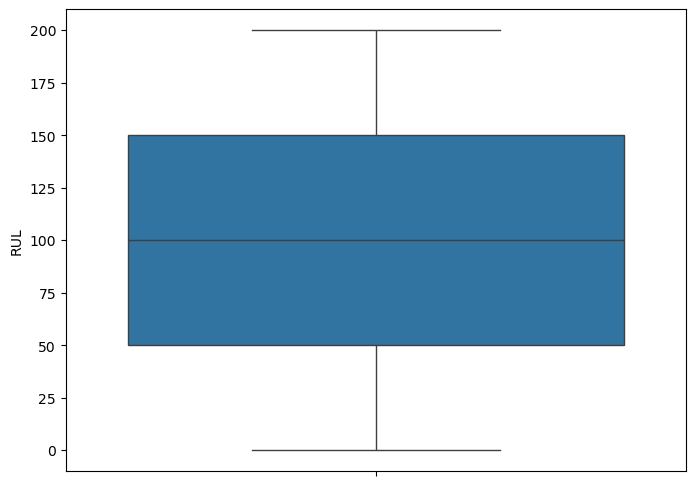

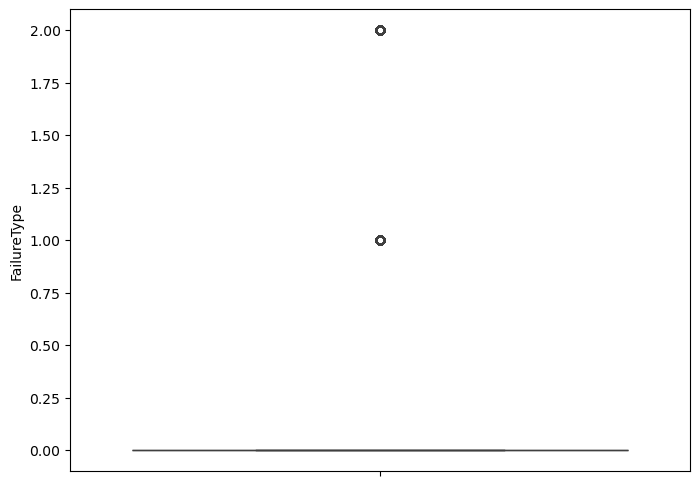

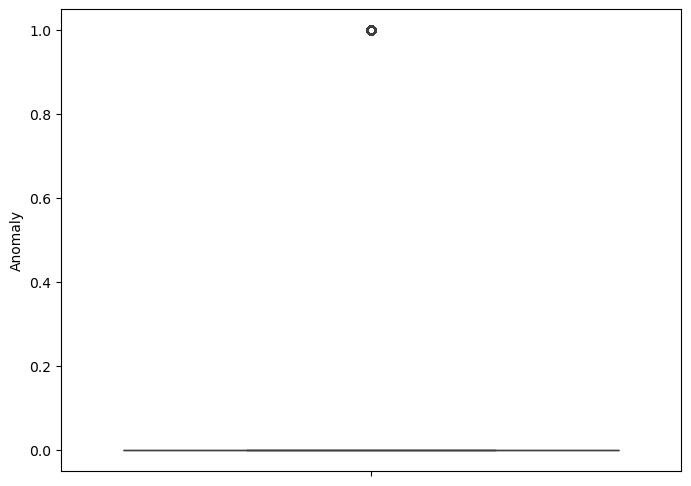

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
for i in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(df[i])

hisplot for distribution

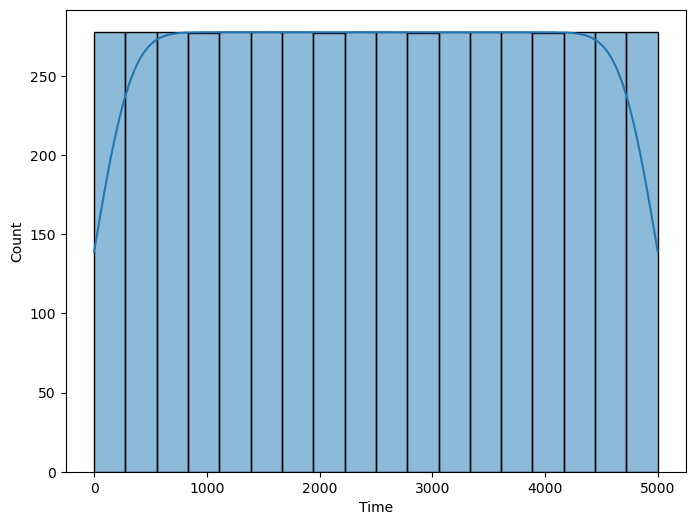

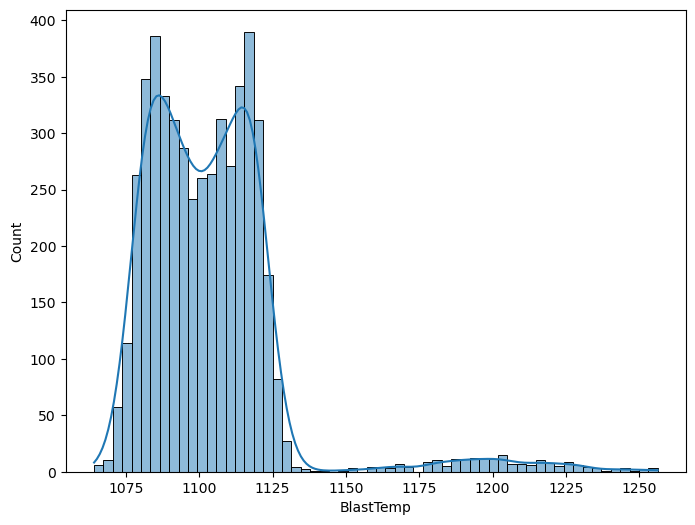

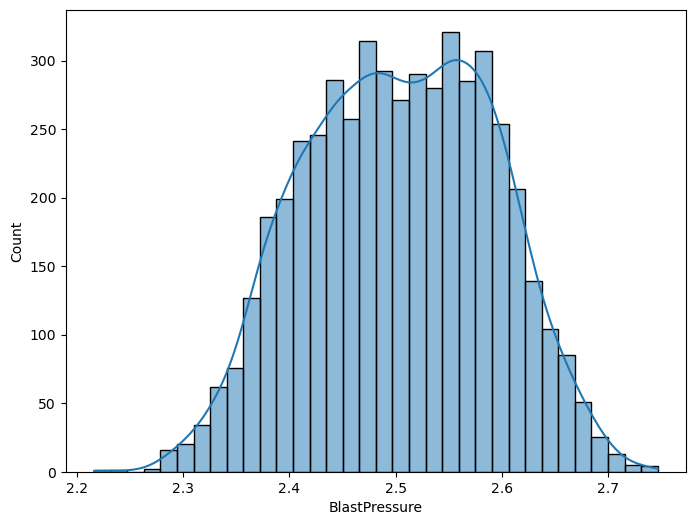

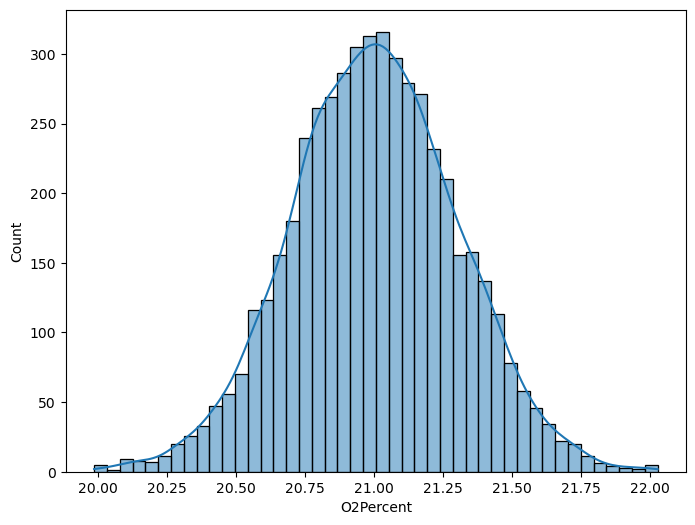

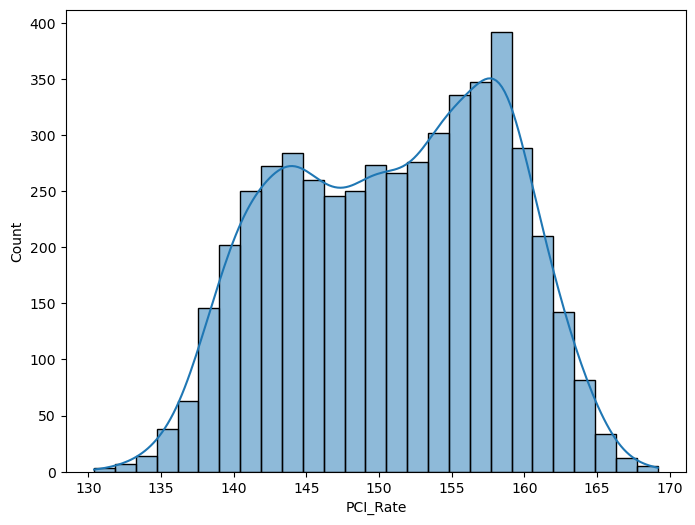

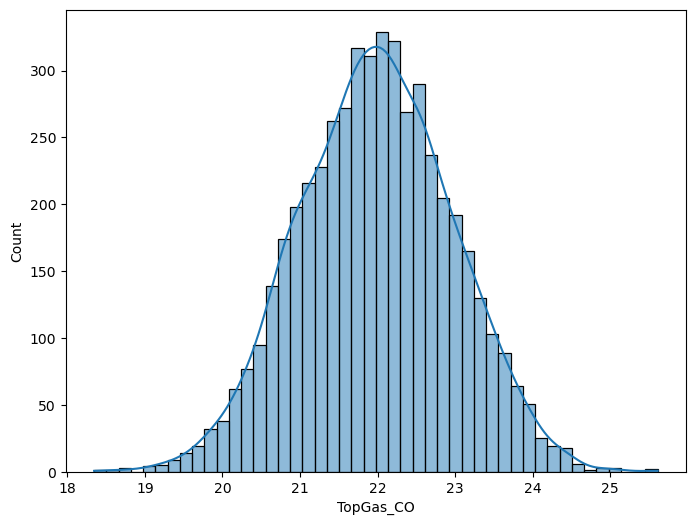

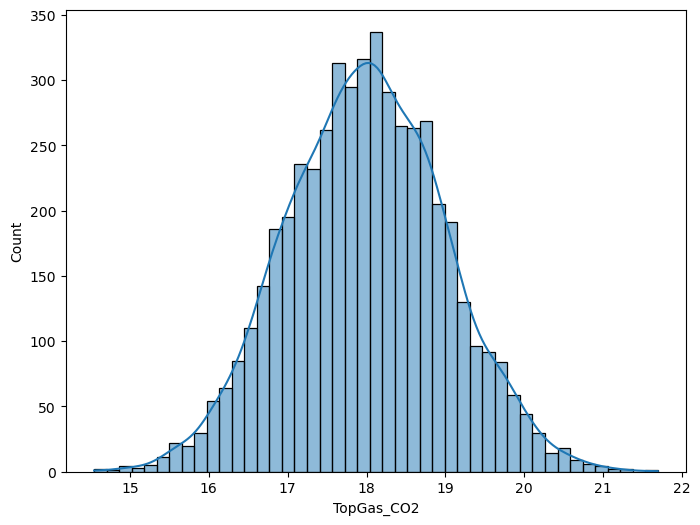

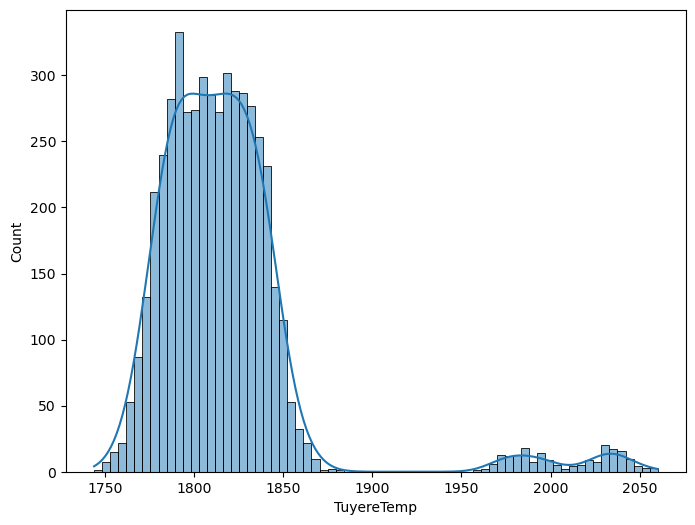

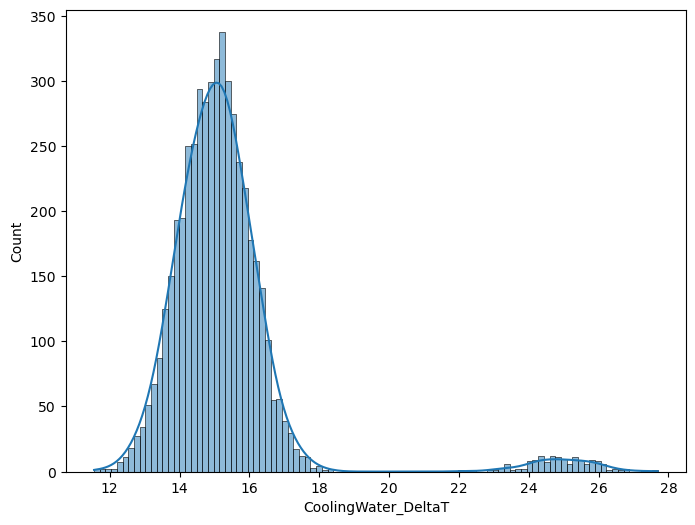

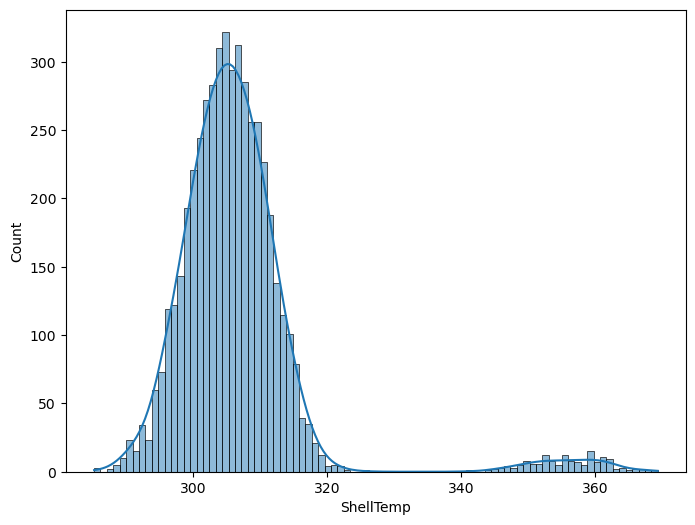

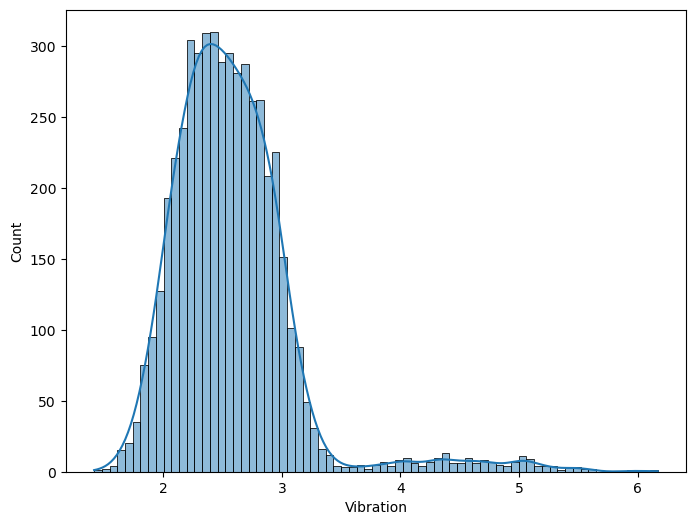

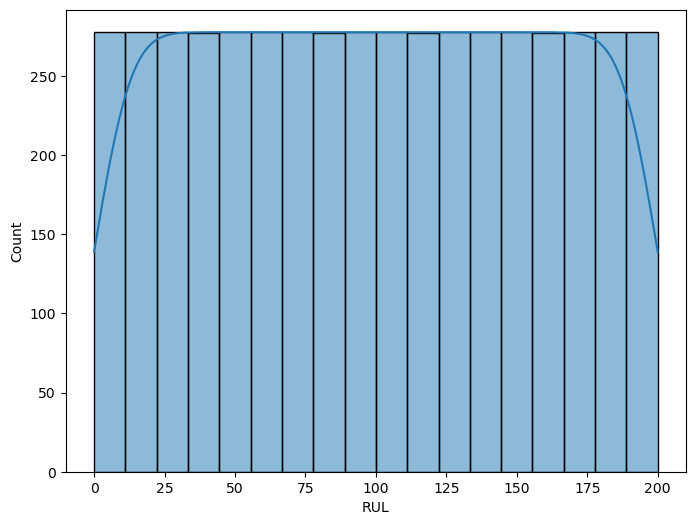

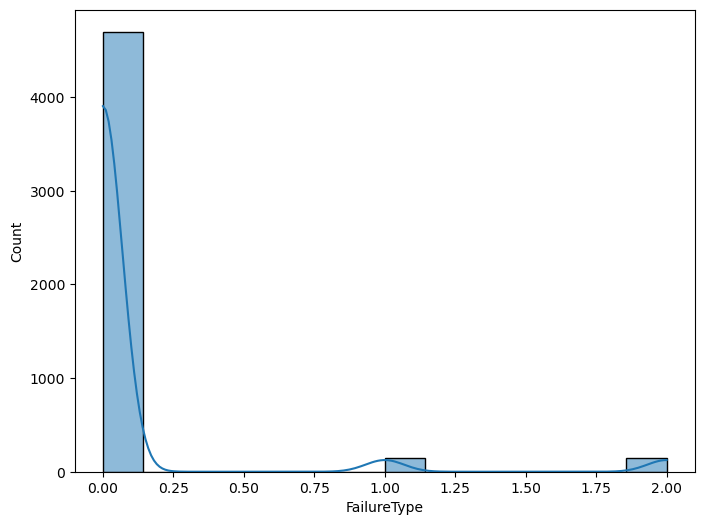

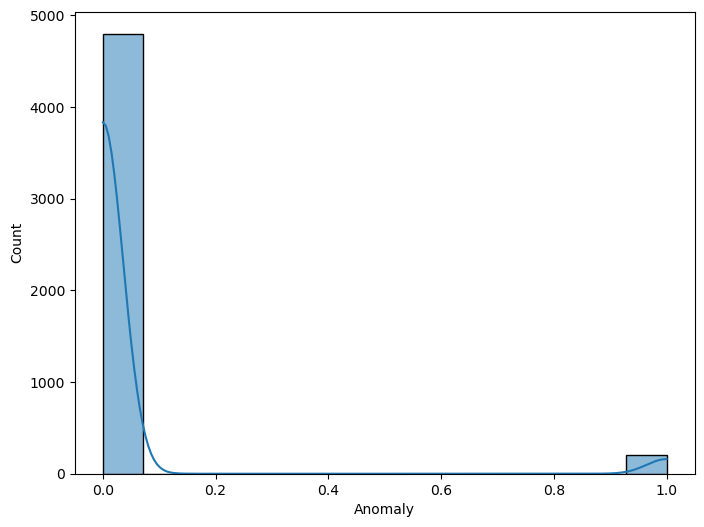

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
for i in df.columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[i], kde=True)



In [9]:
df.columns

Index(['Time', 'BlastTemp', 'BlastPressure', 'O2Percent', 'PCI_Rate',
       'TopGas_CO', 'TopGas_CO2', 'TuyereTemp', 'CoolingWater_DeltaT',
       'ShellTemp', 'Vibration', 'RUL', 'FailureType', 'Anomaly'],
      dtype='object')

define feature

In [10]:
df_model = df.copy()

df_model = df_model.drop(columns=['Time', 'FailureType', 'Anomaly','RUL'])

this is the step fof accure better accuracy

this the step to acquire best accuracy droping the anomaly

In [11]:
train_df = df[df['Anomaly']==0]
test_df = df.copy()

In [12]:
features = ['BlastTemp', 'BlastPressure', 'O2Percent', 'PCI_Rate',
       'TopGas_CO', 'TopGas_CO2', 'TuyereTemp', 'CoolingWater_DeltaT',
       'ShellTemp', 'Vibration']

scalling data Using Standerd Scaler for scale them into standerd from

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(train_df[features])
x_test = scaler.transform(test_df[features])
y_true = (test_df['Anomaly'] == 1).astype(int)

defining model

In [16]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    max_samples=0.5,
    max_features=0.7,
    bootstrap=True,
    random_state=42
)

iso.fit(x_train)

,n_estimators,100
,max_samples,0.5
,contamination,0.01
,max_features,0.7
,bootstrap,True
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [17]:
test_df["Anomaly_score"] = - iso.decision_function(x_test)
test_df["Anomaly_score"]

0      -0.186518
1      -0.168302
2      -0.180808
3      -0.190915
4      -0.165046
          ...   
4995   -0.144039
4996   -0.147324
4997   -0.149180
4998   -0.139962
4999   -0.125864
Name: Anomaly_score, Length: 5000, dtype: float64

In [18]:
from sklearn.metrics import classification_report, confusion_matrix,roc_curve,precision_recall_curve,f1_score,auc,ConfusionMatrixDisplay

In [19]:
y_score = test_df['Anomaly_score'].values

In [20]:
fpr,tpr,thresholds = roc_curve(y_true,y_score)
roc_auc = auc(fpr,tpr)
#

In [21]:
prec,rec,Pr_thresholds = precision_recall_curve(y_true,y_score)

In [22]:
pr_auc = auc(rec,prec)

In [23]:
f1_scores = 2*prec*rec/(prec+rec)+1e-9
#

In [24]:
best_index = np.argmax(f1_scores)
best_threshold = Pr_thresholds[best_index]

In [25]:
test_df['anomaly_flag'] = (test_df['Anomaly_score'] > best_threshold).astype(int)
#

In [26]:
classification_report(y_true,test_df['anomaly_flag'])
#

'              precision    recall  f1-score   support\n\n           0       1.00      0.95      0.97      4800\n           1       0.44      0.97      0.61       200\n\n    accuracy                           0.95      5000\n   macro avg       0.72      0.96      0.79      5000\nweighted avg       0.98      0.95      0.96      5000\n'

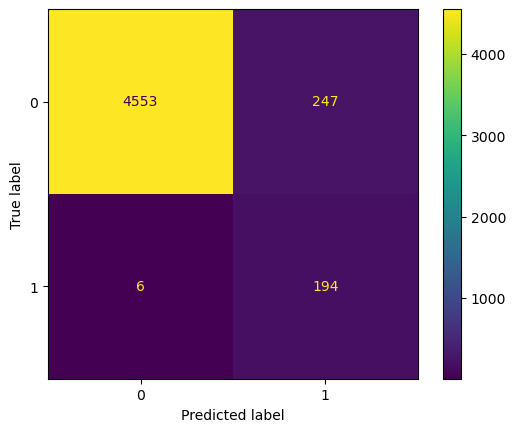

In [27]:
ConfusionMatrixDisplay(confusion_matrix(y_true,test_df['anomaly_flag'])).plot()
#

In [28]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_train)

In [29]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense

def buildautoencoder(input_dim):
  Encoder = Sequential([Dense(32, activation='relu', input_shape=(input_dim,)),
                        Dense(16, activation='relu'),
                        Dense(8, activation='relu')])
  Decoder = Sequential([Dense(16, activation='relu', input_shape=(8,)),
                        Dense(32, activation='relu'),
                        Dense(input_dim, activation='sigmoid')])
  inputs = Input(shape=(input_dim,))
  Latent = Encoder(inputs)
  Output = Decoder(Latent)

  return Model(inputs, Output),Encoder
input_dim = x_train.shape[1]
autoencoder,encoder = buildautoencoder(input_dim)
autoencoder.compile(optimizer='adam', loss='mse')
#

/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
autoencoder.fit(x_train,X_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9787 - val_loss: 1.0534
Epoch 2/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7414 - val_loss: 1.0093
Epoch 3/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6695 - val_loss: 0.8994
Epoch 4/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6367 - val_loss: 0.8451
Epoch 5/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6149 - val_loss: 0.8177
Epoch 6/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6087 - val_loss: 0.8101
Epoch 7/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6059 - val_loss: 0.8114
Epoch 8/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6058 - val_loss: 0.8085
Epoch 9/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6167 - val_loss: 0.8119
Epoch 10/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6429 - val_loss: 0.8340
Epoch 11/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6539 - val_loss: 0.8467
Epoch 12/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 

In [31]:
recons = autoencoder.predict(x_test)
mse = np.mean(np.power(x_test - recons, 2), axis=1)

df['ae_error'] = mse

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [32]:
from sklearn.metrics import classification_report, confusion_matrix,roc_curve,precision_recall_curve,f1_score,auc,ConfusionMatrixDisplay

In [33]:
y_pred = df['ae_error']

In [34]:
fp,tp,thres = roc_curve(y_true,y_pred)
roc_auc = auc(fp,tp)

In [35]:
pre,re,Pr_thres = precision_recall_curve(y_true,y_pred)

In [36]:
pr_auc = auc(re,pre)

In [37]:
f1_sco = 2*pre*re/(pre+re)+1e-9

In [38]:
best_ind = np.argmax(f1_scores)
best_thres = Pr_thres[best_ind]

In [39]:
test_df['anomaly_sign'] = (df['ae_error'] > best_thres).astype(int)

In [40]:
classification_report(y_true,test_df['anomaly_sign'])

'              precision    recall  f1-score   support\n\n           0       1.00      0.95      0.97      4800\n           1       0.45      1.00      0.62       200\n\n    accuracy                           0.95      5000\n   macro avg       0.73      0.97      0.80      5000\nweighted avg       0.98      0.95      0.96      5000\n'

In [41]:
threshold = np.percentile(mse, 95)  # top 5% anomalies

df['ae_anomaly'] = (df['ae_error'] > threshold).astype(int)

In [42]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(df['Anomaly'], test_df['anomaly_sign']))
print(classification_report(df['Anomaly'], test_df['anomaly_sign']))

[[4559  241]
 [   0  200]]
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97      4800
         1.0       0.45      1.00      0.62       200

    accuracy                           0.95      5000
   macro avg       0.73      0.97      0.80      5000
weighted avg       0.98      0.95      0.96      5000



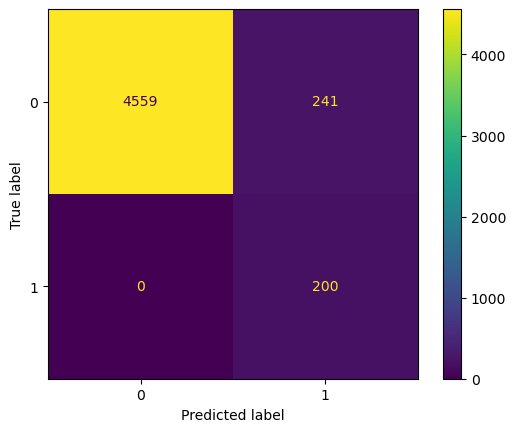

In [43]:
ConfusionMatrixDisplay(confusion_matrix(y_true,test_df['anomaly_sign'])).plot()

In [44]:
test_df['final_anomaly'] = (
    (test_df['anomaly_flag'] == 1) | (test_df['anomaly_sign'] == 1)
).astype(int)

In [45]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(df['Anomaly'], test_df['final_anomaly']))
print(classification_report(df['Anomaly'], test_df['final_anomaly']))

[[4496  304]
 [   0  200]]
              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97      4800
         1.0       0.40      1.00      0.57       200

    accuracy                           0.94      5000
   macro avg       0.70      0.97      0.77      5000
weighted avg       0.98      0.94      0.95      5000



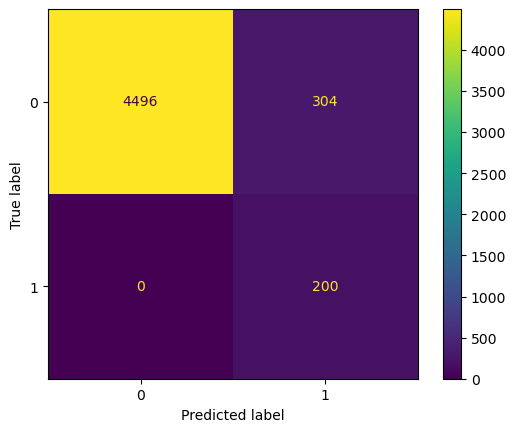

In [46]:
ConfusionMatrixDisplay(confusion_matrix(y_true,test_df['final_anomaly'])).plot()

In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(df['Anomaly'], test_df['final_anomaly'])
print("Accuracy:", accuracy)

Accuracy: 0.9392


In [48]:
print(df['Anomaly'].value_counts())

Anomaly
0.0    4800
1.0     200
Name: count, dtype: int64


In [50]:
print(test_df['final_anomaly'].value_counts())

final_anomaly
0    4496
1     504
Name: count, dtype: int64


dumping model for use in dashboard

In [57]:
import joblib
joblib.dump(iso, 'anomaly_model.pkl')

['anomaly_model.pkl']